# LOO Ablation — Publication-quality plots

Visualises results from `results/ablation_loo.csv` (generated by `ablation_loo.py`).

**Three figures:**
1. CF metrics — holdout (OOD) vs in-distribution, targets pooled
2. CF metrics — split by target (CRC / TVA)
3. Run-level metrics (ARI, NMI, marginal log-likelihood)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ── Nature-style rcParams ─────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":        "monospace",
    "font.sans-serif":    ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":          7,
    "axes.labelsize":     7,
    "axes.titlesize":     8,
    "axes.linewidth":     0.8,
    "xtick.labelsize":    6,
    "ytick.labelsize":    6,
    "xtick.major.width":  0.8,
    "ytick.major.width":  0.8,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "legend.fontsize":    6,
    "legend.frameon":     False,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "pdf.fonttype":       42,   # editable fonts in PDF
    "ps.fonttype":        42,
})

In [2]:
# ── Load & preprocess ─────────────────────────────────────────────────────────
df = pd.read_csv("results/ablation_loo_brain.csv")
df["lpw_str"] = df["link_prediction_weight"].astype(str)

# ── Plot configuration toggle ─────────────────────────────────────────────────
# "cellina-graph" : supcon + domain_clf
# "cellina-base"  : cellina-base only
PLOT_CONFIG = "cellina-graph"

if PLOT_CONFIG == "cellina-graph":
    SLT_ORDER = ["supcon", "domain_clf"]
    X_LABEL   = "Spatial loss lambda"
else:  # cellina-base
    SLT_ORDER = ["cellina-base"]
    X_LABEL   = "Domain classifier lambda"

# Derive LPW_ORDER from the data (exclude lpw=0 baseline rows; sort numerically)
_lpw_pool       = df[df["spatial_loss_type"].isin(SLT_ORDER)]["lpw_str"].unique()
LPW_ORDER       = sorted([v for v in _lpw_pool if v != "0.0"], key=lambda s: float(s))
LPW_TICK_LABELS = LPW_ORDER

SLT_COLORS  = {"supcon": "#4C72B0", "domain_clf": "#C44E52", "cellina-base": "#8172B2"}  # colorblind-friendly
SLT_HATCHES = {"supcon": "",        "domain_clf": "//", "cellina-base": "xx"}    # B&W-friendly
SLT_LABELS  = {"supcon": "SupCon",  "domain_clf": "Domain clf", "cellina-base": "Cellina-Base"}

CF_METRICS  = ["pearson_r", "spearman_r", "precision", "mixing_index", "edistance", "rmse"]
RUN_METRICS = ["marginal_ll", "ari", "nmi",
               "ari_s_labels", "nmi_s_labels",
               "ari_z_domains", "nmi_z_domains"]

METRIC_LABELS = {
    "pearson_r":    "Pearson r",
    "spearman_r":   "Spearman r",
    "precision":    "Precision@50",
    "mixing_index": "Mixing index",
    "edistance":    "Energy distance",
    "rmse":         "RMSE",
    "marginal_ll":  "Marginal log-likelihood",
    "ari":          "ARI",
    "nmi":          "NMI",
    "ari_s_labels":  "ARI (s vs labels)",
    "nmi_s_labels":  "NMI (s vs labels)",
    "ari_z_domains": "ARI (z vs domains)",
    "nmi_z_domains": "NMI (z vs domains)",
}

print(f"Rows: {len(df)}")
print(f"LPW_ORDER: {LPW_ORDER}")

Rows: 627
LPW_ORDER: ['1e-05', '0.01', '0.1', '1.0', '100.0']


In [3]:
df

,holdout_celltype,spatial_loss_type,link_prediction_weight,target,cell_type,is_holdout,n_ref,n_target,pearson_r,spearman_r,...,edistance,rmse,marginal_ll,ari,nmi,ari_s_labels,nmi_s_labels,ari_z_domains,nmi_z_domains,lpw_str
0,glutamatergic neuron,supcon,0.0,Thalamus,GABAergic neuron,False,1041,467,0.917991,0.815990,...,548.131226,1.341924,-551.252529,0.455705,0.568372,0.051576,0.157925,0.116170,0.167595,0.0
1,glutamatergic neuron,supcon,0.0,Thalamus,astrocyte,False,1295,1230,0.975452,0.894070,...,604.467163,0.547555,-551.252529,0.455705,0.568372,0.051576,0.157925,0.116170,0.167595,0.0
2,glutamatergic neuron,supcon,0.0,Thalamus,endothelial cell,False,1256,996,0.988567,0.958992,...,517.977661,0.458264,-551.252529,0.455705,0.568372,0.051576,0.157925,0.116170,0.167595,0.0
3,glutamatergic neuron,supcon,0.0,Thalamus,glutamatergic neuron,True,7730,3521,0.963390,0.905690,...,759.882202,1.269472,-551.252529,0.455705,0.568372,0.051576,0.157925,0.116170,0.167595,0.0
4,glutamatergic neuron,supcon,0.0,Thalamus,microglial cell,False,529,275,0.966829,0.848643,...,490.969116,0.740144,-551.252529,0.455705,0.568372,0.051576,0.157925,0.116170,0.167595,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
622,astrocyte,domain_clf,100.0,Hippocampus,microglial cell,False,529,275,0.943965,0.809844,...,597.568726,0.657819,-463.398132,0.971530,0.949718,0.098265,0.115538,0.073079,0.144931,100.0
623,astrocyte,domain_clf,100.0,Hippocampus,oligodendrocyte,False,628,695,0.866571,0.625162,...,1462.271729,1.141011,-463.398132,0.971530,0.949718,0.098265,0.115538,0.073079,0.144931,100.0
624,astrocyte,domain_clf,100.0,Hippocampus,oligodendrocyte precursor cell,False,308,198,0.894374,0.790924,...,460.516602,0.795307,-463.398132,0.971530,0.949718,0.098265,0.115538,0.073079,0.144931,100.0
625,astrocyte,domain_clf,100.0,Hippocampus,pericyte,False,258,116,0.881330,0.690660,...,476.212280,0.857612,-463.398132,0.971530,0.949718,0.098265,0.115538,0.073079,0.144931,100.0


In [4]:
# df = df[df['holdout_celltype'].isin(['Epithelial', 'T_cell'])] 

In [5]:
# ── Aggregation helpers ───────────────────────────────────────────────────────

def sem(x):
    """Standard error of mean."""
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0


def agg_cf(df, is_holdout_val, target=None):
    """Mean ± SEM of CF metrics across cell types / holdout conditions / targets."""
    sub = df[df["is_holdout"] == is_holdout_val]
    if target is not None:
        sub = sub[sub["target"] == target]
    g = sub.groupby(["lpw_str", "spatial_loss_type"])
    result = {}
    for metric in CF_METRICS:
        m = g[metric].agg(["mean", sem]).reset_index()
        m.columns = ["lpw_str", "spatial_loss_type", "mean", "sem"]
        result[metric] = m
    return result


def agg_run(df):
    """Mean ± SEM of run metrics across holdout cell types (one row per run)."""
    run_df = df.drop_duplicates(["holdout_celltype", "link_prediction_weight", "spatial_loss_type"])
    g = run_df.groupby(["lpw_str", "spatial_loss_type"])
    result = {}
    for metric in RUN_METRICS:
        m = g[metric].agg(["mean", sem]).reset_index()
        m.columns = ["lpw_str", "spatial_loss_type", "mean", "sem"]
        result[metric] = m
    return result


def baseline_vals(agg_metric_df):
    """Return {slt: lpw=0 mean} for each method that has a lpw=0 row."""
    result = {}
    for slt in ["supcon", "cellina-base"]:
        sub = agg_metric_df[
            (agg_metric_df["lpw_str"] == "0.0") &
            (agg_metric_df["spatial_loss_type"] == slt)
        ]
        if len(sub):
            result[slt] = float(sub["mean"].iloc[0])
    return result

In [6]:
# ── Core barplot helper ───────────────────────────────────────────────────────

def grouped_barplot(
    ax, metric_df, lpw_order, slt_order,
    slt_colors, slt_hatches, slt_labels,
    tick_labels=None,
    baseline=None,      # dict {slt: scalar} — drawn as colored dashed lines (lpw=0 baselines)
    ylabel=None, title=None, show_legend=False, show_xlabel=True,
    ylim=None,
):
    """
    metric_df  : DataFrame with columns [lpw_str, spatial_loss_type, mean, sem]
    baseline   : dict {slt: float} — if provided, draw one dashed reference line per entry
    show_xlabel: set False to suppress the x-axis label (non-bottom panels)
    """
    if tick_labels is None:
        tick_labels = lpw_order

    n_slt  = len(slt_order)
    bar_w  = 0.38
    group_w = bar_w * n_slt + 0.12
    x      = np.arange(len(lpw_order)) * group_w
    offsets = np.linspace(-(n_slt - 1) / 2, (n_slt - 1) / 2, n_slt) * bar_w

    for i, slt in enumerate(slt_order):
        sub   = metric_df[metric_df["spatial_loss_type"] == slt].set_index("lpw_str")
        means = [sub.loc[lpw, "mean"] if lpw in sub.index else np.nan for lpw in lpw_order]
        sems  = [sub.loc[lpw, "sem"]  if lpw in sub.index else np.nan for lpw in lpw_order]
        ax.bar(
            x + offsets[i], means, bar_w * 0.92,
            yerr=sems, capsize=2.0,
            color=slt_colors[slt], hatch=slt_hatches[slt],
            edgecolor="white", linewidth=0.5,
            label=slt_labels[slt],
            error_kw=dict(linewidth=0.8, ecolor="0.25", capthick=0.8),
            zorder=3,
        )

    if baseline:
        for slt, val in baseline.items():
            ax.axhline(
                val,
                linestyle="--",
                color=slt_colors.get(slt, "0.40"),
                linewidth=0.9,
                label=f"{slt_labels.get(slt, slt)} baseline (lpw=0)",
                zorder=4,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, fontsize=6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linewidth=0.4, color="0.85", zorder=0)
    ax.set_axisbelow(True)

    if show_xlabel: ax.set_xlabel(X_LABEL, fontsize=7, labelpad=2)
    if ylabel:      ax.set_ylabel(ylabel, fontsize=7, labelpad=3)
    if title:       ax.set_title(title, fontsize=8, pad=3)
    if ylim:        ax.set_ylim(*ylim)
    # if show_legend: ax.legend(fontsize=6, frameon=False, handlelength=1.4)

## Figure 1 — CF metrics: LOO (OOD) vs in-distribution  *(targets pooled)*

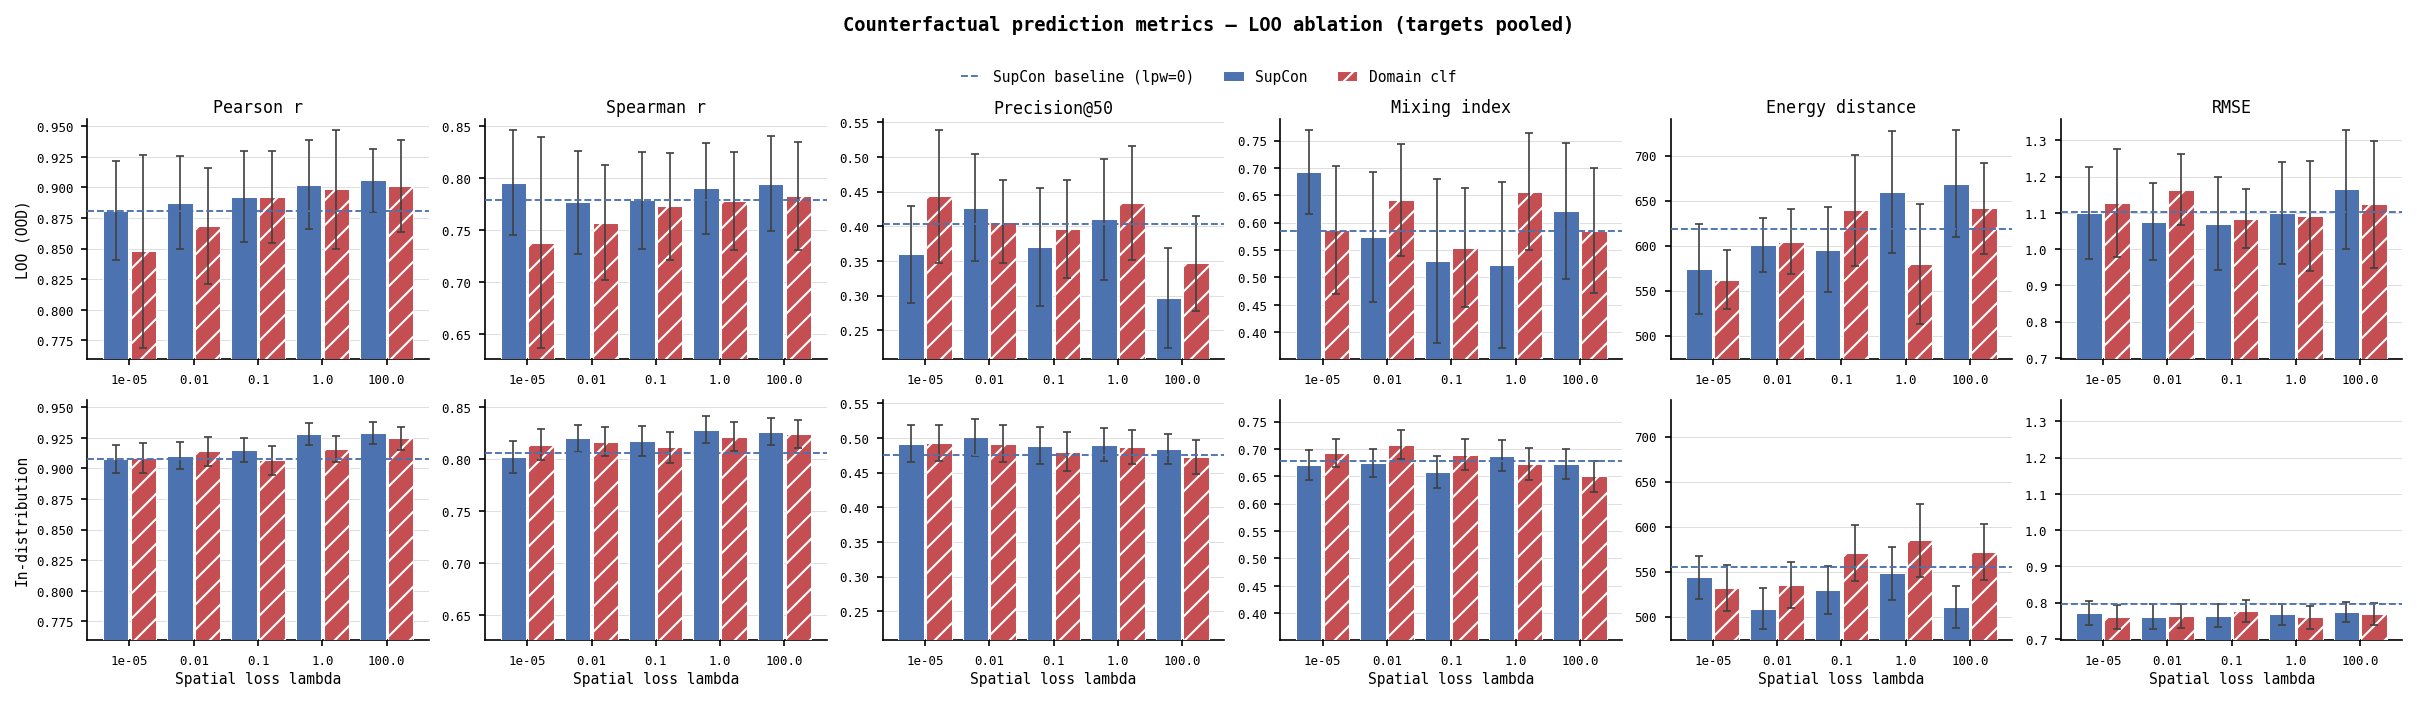

In [7]:
agg_holdout = agg_cf(df, is_holdout_val=True)
agg_inDist  = agg_cf(df, is_holdout_val=False)

def shared_ylims(agg_dict_list, metrics, pad=0.05):
    ylims = {}
    for m in metrics:
        vals = pd.concat([d[m] for d in agg_dict_list])
        lo = (vals["mean"] - vals["sem"]).min()
        hi = (vals["mean"] + vals["sem"]).max()
        rng = hi - lo
        ylims[m] = (max(0, lo - pad * rng), hi + pad * rng)
    return ylims

ylims1 = shared_ylims([agg_holdout, agg_inDist], CF_METRICS)

fig1, axes1 = plt.subplots(2, 6, figsize=(16, 4), constrained_layout=True)

row_labels = ["LOO (OOD)", "In-distribution"]
agg_rows   = [agg_holdout, agg_inDist]
is_bottom  = [False, True]

for row_i, (row_label, agg_dict, bottom) in enumerate(zip(row_labels, agg_rows, is_bottom)):
    for col_i, metric in enumerate(CF_METRICS):
        ax = axes1[row_i, col_i]
        grouped_barplot(
            ax, agg_dict[metric],
            lpw_order=LPW_ORDER, tick_labels=LPW_TICK_LABELS,
            slt_order=SLT_ORDER,
            slt_colors=SLT_COLORS, slt_hatches=SLT_HATCHES, slt_labels=SLT_LABELS,
            baseline=baseline_vals(agg_dict[metric]),
            title=METRIC_LABELS[metric] if row_i == 0 else None,
            ylabel=row_label if col_i == 0 else None,
            show_xlabel=bottom,
            ylim=ylims1[metric],
        )

handles, labels = axes1[0, 0].get_legend_handles_labels()
fig1.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.06),
            ncols=len(handles), fontsize=7, frameon=False, handlelength=1.4)
fig1.suptitle("Counterfactual prediction metrics — LOO ablation (targets pooled)",
              fontsize=9, weight="bold", y=1.13)
plt.show()

## Figure 2 — CF metrics split by target (CRC vs TVA)

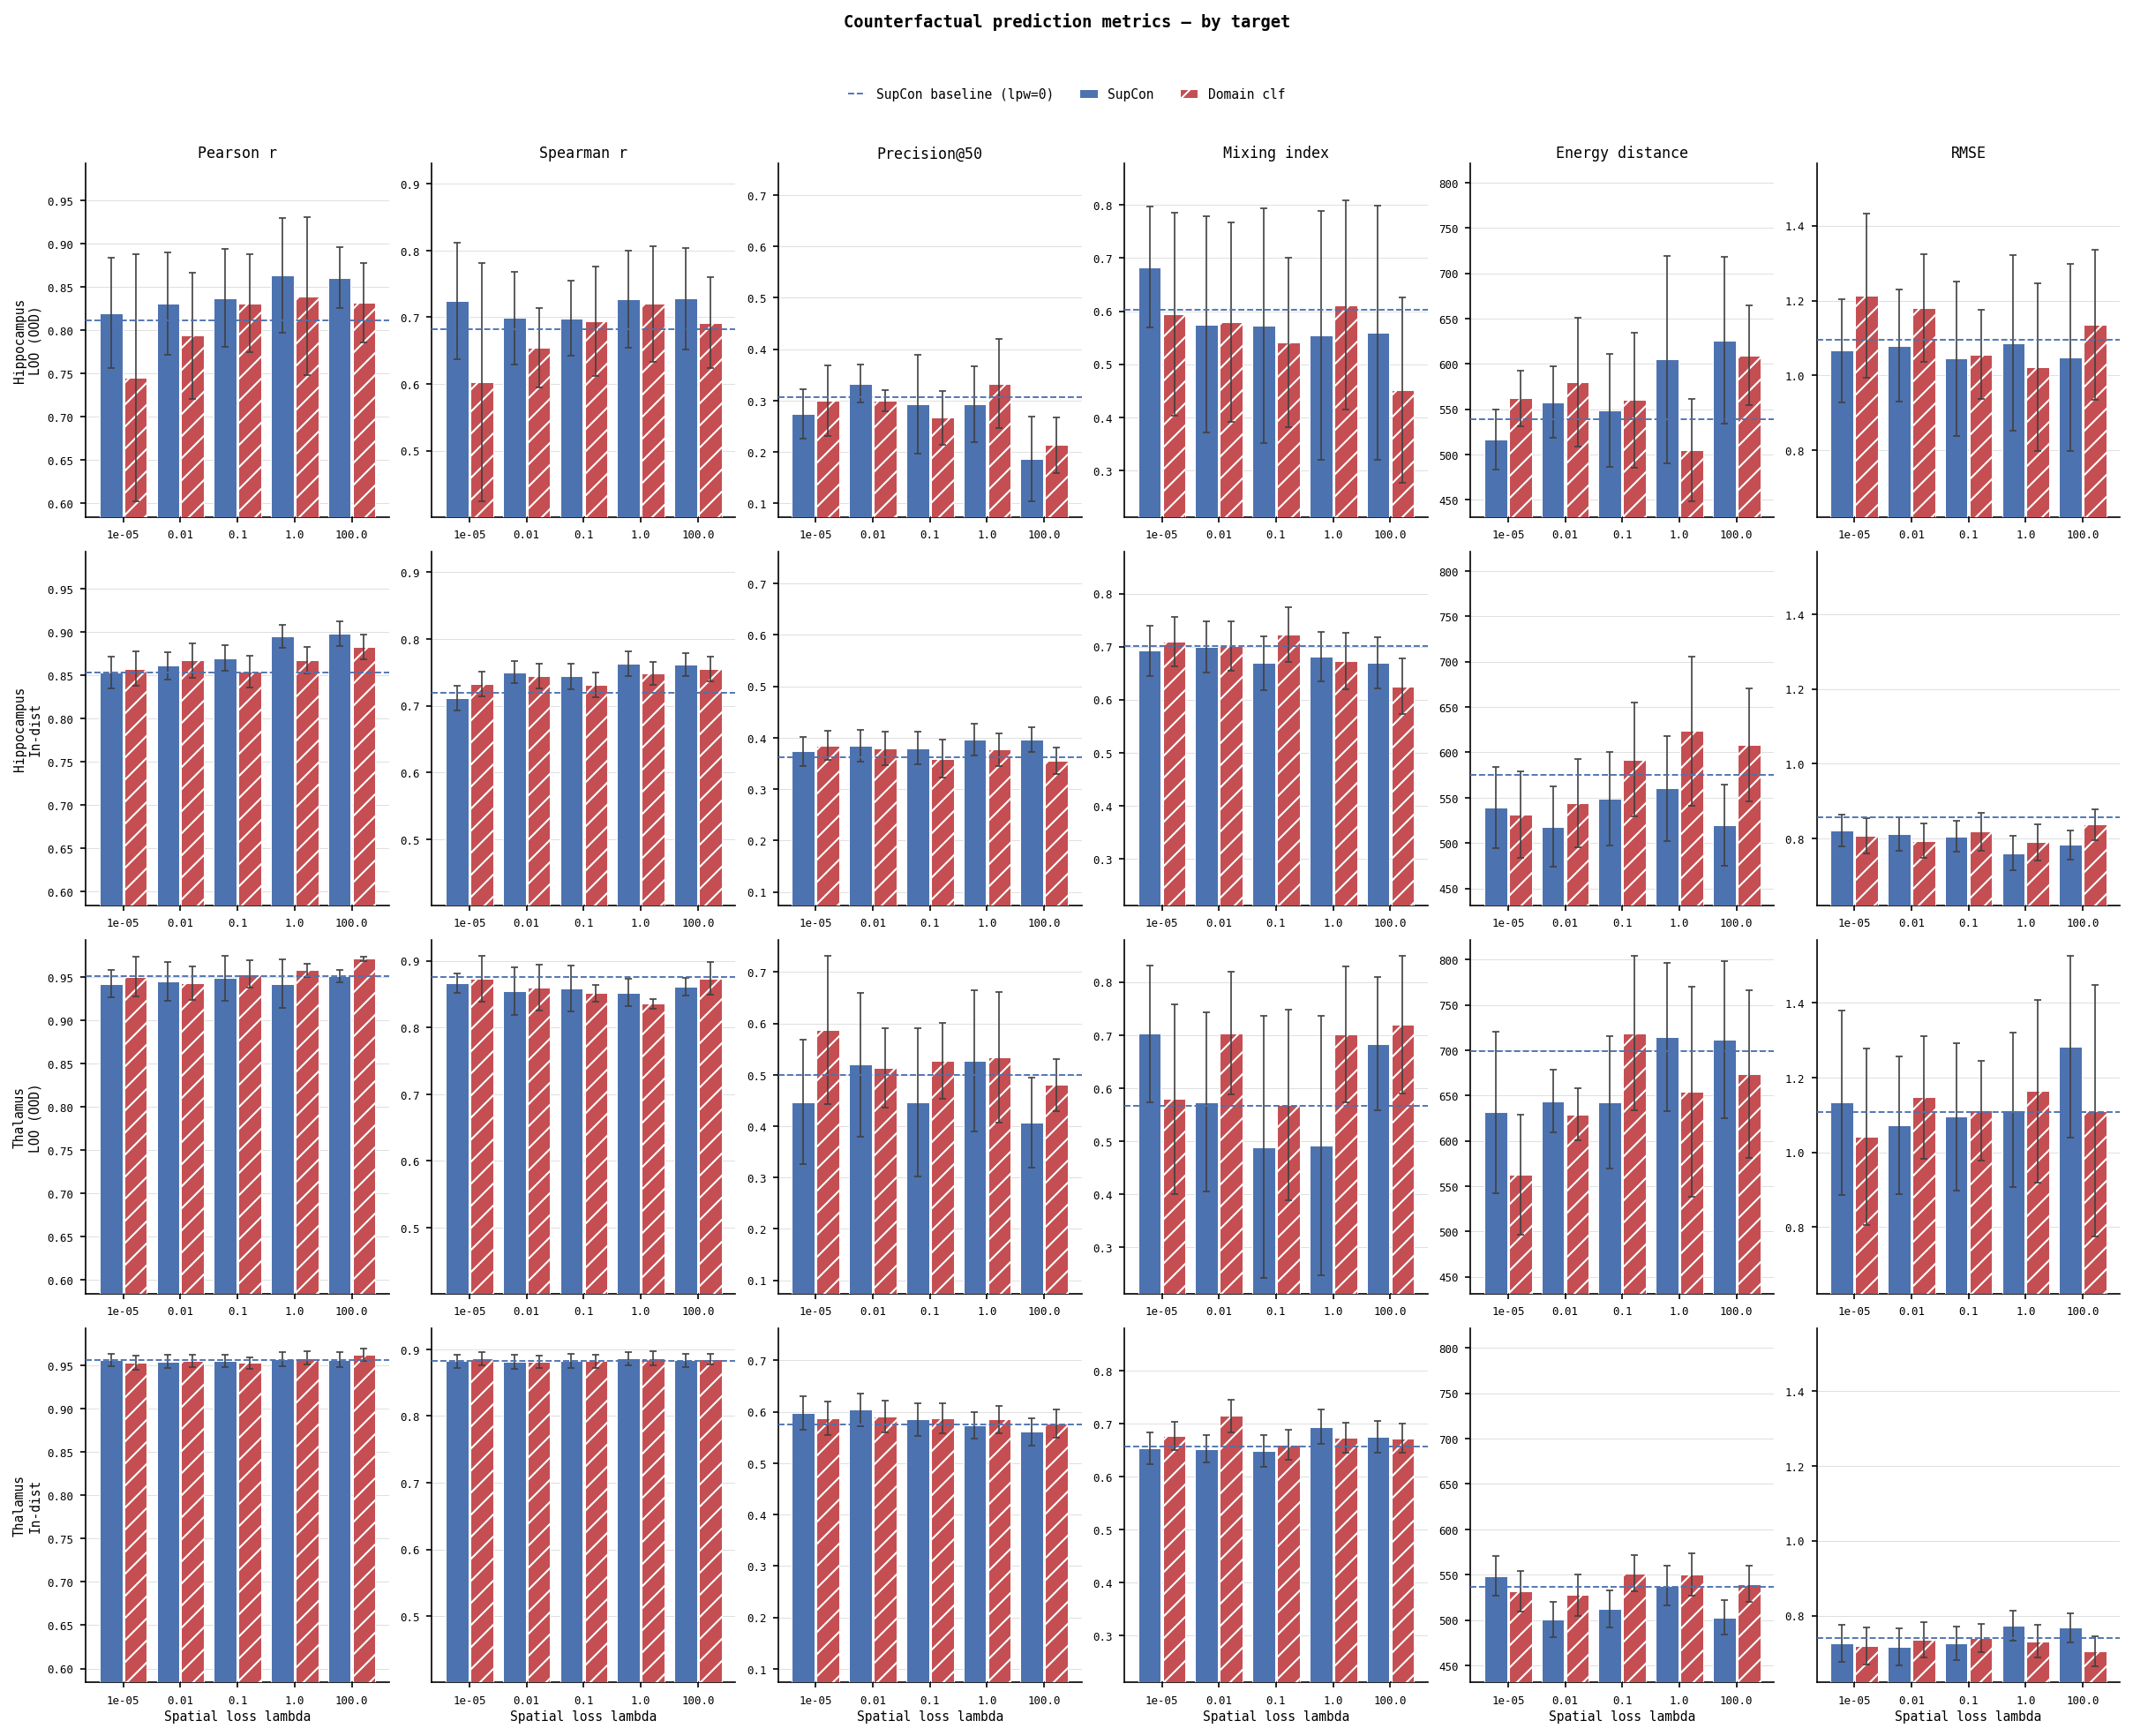

In [8]:
TARGETS = sorted(df["target"].unique())

agg_by_target = {
    tgt: {
        "holdout": agg_cf(df, is_holdout_val=True,  target=tgt),
        "inDist":  agg_cf(df, is_holdout_val=False, target=tgt),
    }
    for tgt in TARGETS
}

all_aggs = [agg_by_target[tgt][cond] for tgt in TARGETS for cond in ["holdout", "inDist"]]
ylims2 = shared_ylims(all_aggs, CF_METRICS)

fig2, axes2 = plt.subplots(len(TARGETS) * 2, 6, figsize=(16, 3 * len(TARGETS) * 2), constrained_layout=True)

cond_keys   = ["holdout", "inDist"]
cond_labels = {"holdout": "LOO (OOD)", "inDist": "In-dist"}
row_ylabels = [f"{tgt}\n{cond_labels[cond]}" for tgt in TARGETS for cond in cond_keys]

for t_i, tgt in enumerate(TARGETS):
    for c_i, cond in enumerate(cond_keys):
        row_i    = t_i * 2 + c_i
        agg_dict = agg_by_target[tgt][cond]
        is_top    = (row_i == 0)
        is_bottom = (row_i == len(TARGETS) * 2 - 1)

        for col_i, metric in enumerate(CF_METRICS):
            ax = axes2[row_i, col_i]
            grouped_barplot(
                ax, agg_dict[metric],
                lpw_order=LPW_ORDER, tick_labels=LPW_TICK_LABELS,
                slt_order=SLT_ORDER,
                slt_colors=SLT_COLORS, slt_hatches=SLT_HATCHES, slt_labels=SLT_LABELS,
                baseline=baseline_vals(agg_dict[metric]),
                title=METRIC_LABELS[metric] if is_top else None,
                ylabel=row_ylabels[row_i] if col_i == 0 else None,
                show_xlabel=is_bottom,
                ylim=ylims2[metric],
            )

handles, labels = axes2[0, 0].get_legend_handles_labels()
fig2.legend(handles, labels, loc="upper center",
            bbox_to_anchor=(0.5, 1.04),
            ncols=len(handles), fontsize=7,
            frameon=False,
            handlelength=1.4)
fig2.suptitle("Counterfactual prediction metrics — by target",
              fontsize=9, weight="bold", y=1.08)
plt.show()

## Figure 3 — Run-level metrics (ARI, NMI, Marginal log-likelihood)

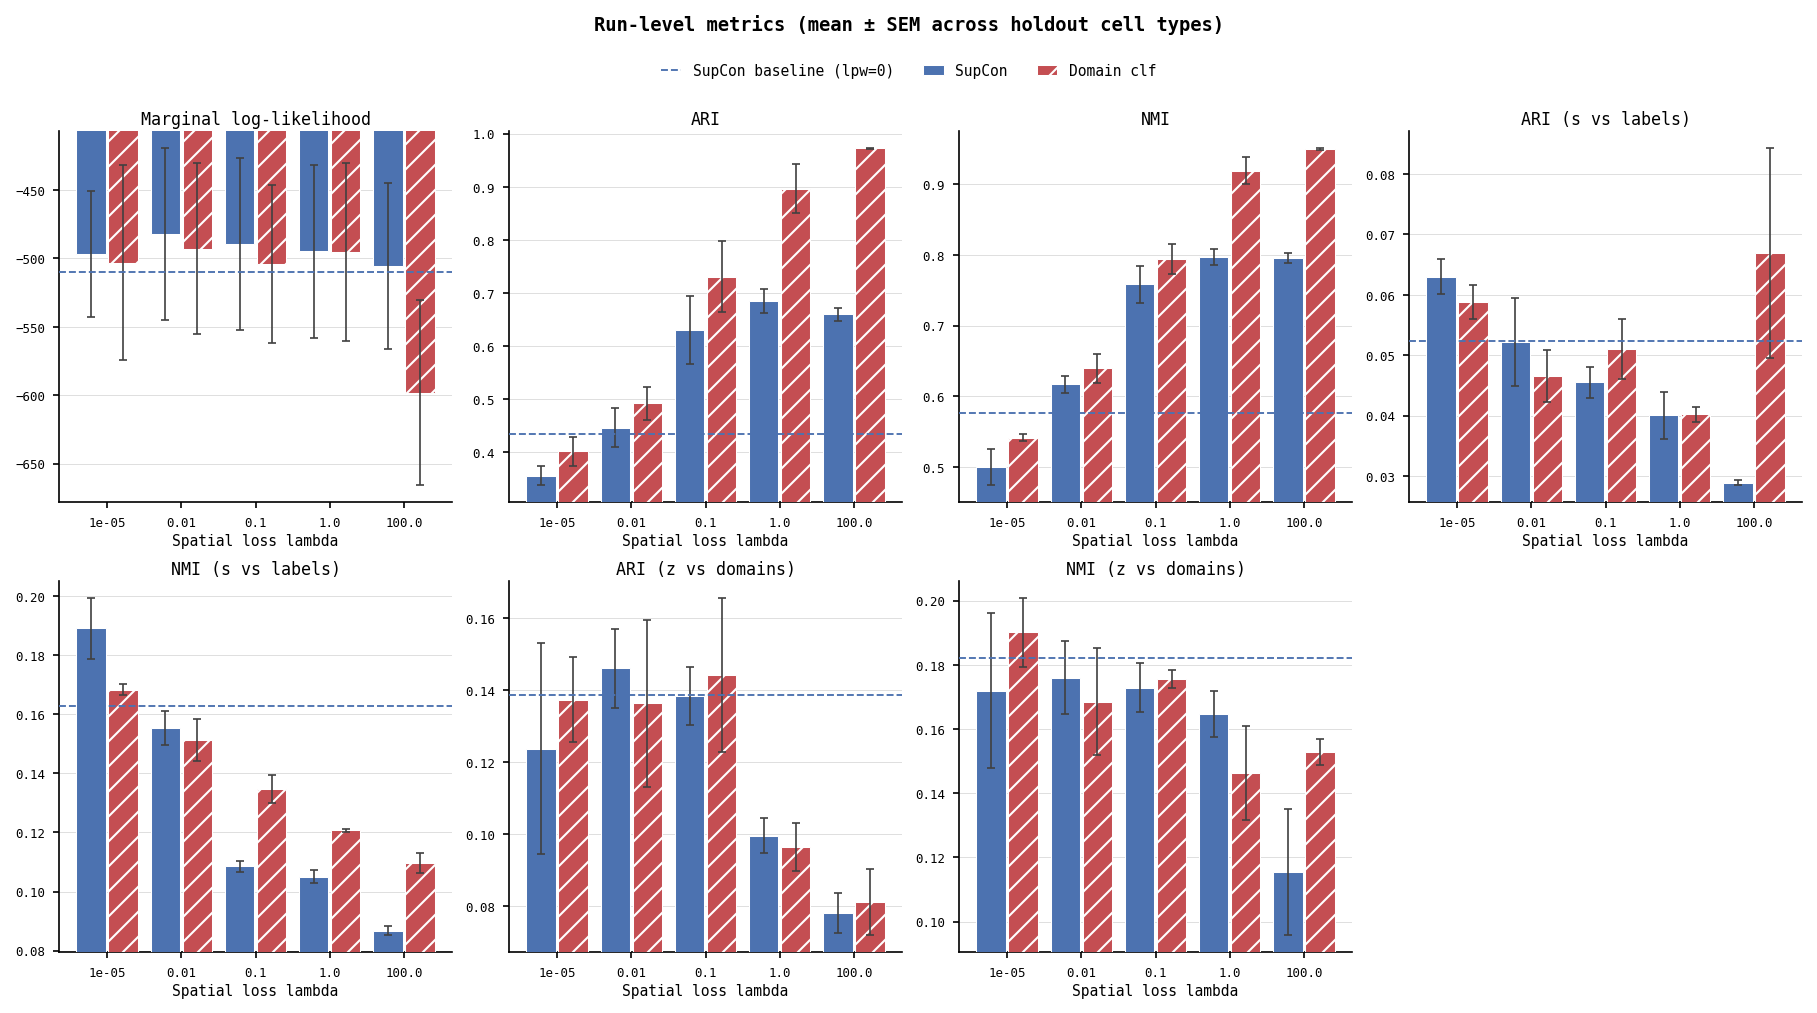

In [9]:
agg_run_dict = agg_run(df)

ncols3 = 4
nrows3 = (len(RUN_METRICS) + ncols3 - 1) // ncols3
fig3, axes3 = plt.subplots(nrows3, ncols3, figsize=(12, 3 * nrows3), constrained_layout=True)
axes3_flat = axes3.flatten()

for col_i, metric in enumerate(RUN_METRICS):
    ax  = axes3_flat[col_i]
    vals = agg_run_dict[metric]
    lo  = (vals["mean"] - vals["sem"]).min()
    hi  = (vals["mean"] + vals["sem"]).max()
    rng = hi - lo
    ylim = (lo - 0.05 * rng, hi + 0.05 * rng)

    grouped_barplot(
        ax, agg_run_dict[metric],
        lpw_order=LPW_ORDER, tick_labels=LPW_TICK_LABELS,
        slt_order=SLT_ORDER,
        slt_colors=SLT_COLORS, slt_hatches=SLT_HATCHES, slt_labels=SLT_LABELS,
        baseline=baseline_vals(agg_run_dict[metric]),
        title=METRIC_LABELS[metric],
        show_xlabel=True,
        ylim=ylim,
    )

for j in range(len(RUN_METRICS), len(axes3_flat)):
    axes3_flat[j].set_visible(False)

handles, labels = axes3_flat[0].get_legend_handles_labels()
fig3.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.06),
            ncols=len(handles), fontsize=7, frameon=False, handlelength=1.4)
fig3.suptitle("Run-level metrics (mean ± SEM across holdout cell types)",
              fontsize=9, weight="bold", y=1.10)
plt.show()

## Save all figures

In [10]:
import os
os.makedirs("results", exist_ok=True)

fig1.savefig("results/fig_cf_summary.pdf",   bbox_inches="tight", dpi=300)
fig2.savefig("results/fig_cf_by_target.pdf", bbox_inches="tight", dpi=300)
fig3.savefig("results/fig_run_metrics.pdf",  bbox_inches="tight", dpi=300)